<a href="https://colab.research.google.com/github/KULDEEPSONI-source/MACHINE-LEARNING/blob/main/Multiple%20Linear%20Regression%20(Practicals).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv('/50_Startups.csv')

In [3]:
df.head(5)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [6]:
# Divide the data into dependents vs independents

X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [7]:
X

array([[165349.2, 136897.8, 471784.1, 'New York'],
       [162597.7, 151377.59, 443898.53, 'California'],
       [153441.51, 101145.55, 407934.54, 'Florida'],
       [144372.41, 118671.85, 383199.62, 'New York'],
       [142107.34, 91391.77, 366168.42, 'Florida'],
       [131876.9, 99814.71, 362861.36, 'New York'],
       [134615.46, 147198.87, 127716.82, 'California'],
       [130298.13, 145530.06, 323876.68, 'Florida'],
       [120542.52, 148718.95, 311613.29, 'New York'],
       [123334.88, 108679.17, 304981.62, 'California'],
       [101913.08, 110594.11, 229160.95, 'Florida'],
       [100671.96, 91790.61, 249744.55, 'California'],
       [93863.75, 127320.38, 249839.44, 'Florida'],
       [91992.39, 135495.07, 252664.93, 'California'],
       [119943.24, 156547.42, 256512.92, 'Florida'],
       [114523.61, 122616.84, 261776.23, 'New York'],
       [78013.11, 121597.55, 264346.06, 'California'],
       [94657.16, 145077.58, 282574.31, 'New York'],
       [91749.16, 114175.79, 29491

In [8]:
y

array([192261.83, 191792.06, 191050.39, 182901.99, 166187.94, 156991.12,
       156122.51, 155752.6 , 152211.77, 149759.96, 146121.95, 144259.4 ,
       141585.52, 134307.35, 132602.65, 129917.04, 126992.93, 125370.37,
       124266.9 , 122776.86, 118474.03, 111313.02, 110352.25, 108733.99,
       108552.04, 107404.34, 105733.54, 105008.31, 103282.38, 101004.64,
        99937.59,  97483.56,  97427.84,  96778.92,  96712.8 ,  96479.51,
        90708.19,  89949.14,  81229.06,  81005.76,  78239.91,  77798.83,
        71498.49,  69758.98,  65200.33,  64926.08,  49490.75,  42559.73,
        35673.41,  14681.4 ])

This code is a standard way to perform **One-Hot Encoding** on a specific column within a dataset using Scikit-Learn. One-Hot Encoding converts categorical data (like "Red," "Blue," "Green") into a numerical format that machine learning models can understand by creating a separate column for each category.

Here is the step-by-step breakdown of how your code works:

---

### 1. The Imports

* **`ColumnTransformer`**: This is a powerful tool that allows you to apply different preprocessing transformations to specific columns of your dataset, while leaving others alone.
* **`OneHotEncoder`**: This is the actual transformer that turns categorical labels into binary vectors (e.g., "Red" becomes `[1, 0, 0]`).

### 2. Setting up `ColumnTransformer`

```python
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [3])],
    remainder='passthrough'
)

```

* **`transformers=[...]`**: This list tells the transformer what to do.
* `'encoder'`: An arbitrary name you give this step.
* `OneHotEncoder()`: The instance of the tool you are using.
* `[3]`: The **index** of the column you want to encode. Python uses 0-based indexing, so `[3]` targets the 4th column in your data.


* **`remainder='passthrough'`**: This is critical. By default, `ColumnTransformer` drops any columns you didn't explicitly transform. Setting this to `'passthrough'` tells it: "Encode the 3rd column, but keep all the other columns exactly as they are."

### 3. Transforming the Data

```python
X = np.array(ct.fit_transform(X))

```

* **`.fit_transform(X)`**: This does two things at once:
1. **`.fit()`**: The encoder "learns" all the unique categories present in column 3.
2. **`.transform()`**: It replaces the original strings in column 3 with the new one-hot encoded binary columns.


* **`np.array(...)`**: `ColumnTransformer` often returns a **Sparse Matrix** (a format that saves memory by storing only non-zero values). Wrapping it in `np.array()` converts it into a dense matrix (a standard array) so you can view the data easily.

---

### Visual Example

Imagine column 3 looks like this:

| Column 3 |
| --- |
| Red |
| Blue |
| Red |

After `fit_transform`, that single column is replaced by **three** columns (one for each unique category):

| Blue | Green | Red |
| --- | --- | --- |
| 0 | 0 | 1 |
| 1 | 0 | 0 |
| 0 | 0 | 1 |

### Summary Checklist

* **Targeting:** You selected column 3 for transformation.
* **Flexibility:** The `remainder` parameter ensured you didn't lose the rest of your data.
* **Standardization:** Using `fit_transform` ensures the encoding is consistent across your data.

Would you like to know how to handle situations where you have more than one categorical column to encode at the same time?

In [9]:
# Feature Encoding - OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')

X = np.array(ct.fit_transform(X))

In [10]:
X


array([[0.0, 0.0, 1.0, 165349.2, 136897.8, 471784.1],
       [1.0, 0.0, 0.0, 162597.7, 151377.59, 443898.53],
       [0.0, 1.0, 0.0, 153441.51, 101145.55, 407934.54],
       [0.0, 0.0, 1.0, 144372.41, 118671.85, 383199.62],
       [0.0, 1.0, 0.0, 142107.34, 91391.77, 366168.42],
       [0.0, 0.0, 1.0, 131876.9, 99814.71, 362861.36],
       [1.0, 0.0, 0.0, 134615.46, 147198.87, 127716.82],
       [0.0, 1.0, 0.0, 130298.13, 145530.06, 323876.68],
       [0.0, 0.0, 1.0, 120542.52, 148718.95, 311613.29],
       [1.0, 0.0, 0.0, 123334.88, 108679.17, 304981.62],
       [0.0, 1.0, 0.0, 101913.08, 110594.11, 229160.95],
       [1.0, 0.0, 0.0, 100671.96, 91790.61, 249744.55],
       [0.0, 1.0, 0.0, 93863.75, 127320.38, 249839.44],
       [1.0, 0.0, 0.0, 91992.39, 135495.07, 252664.93],
       [0.0, 1.0, 0.0, 119943.24, 156547.42, 256512.92],
       [0.0, 0.0, 1.0, 114523.61, 122616.84, 261776.23],
       [1.0, 0.0, 0.0, 78013.11, 121597.55, 264346.06],
       [0.0, 0.0, 1.0, 94657.16, 145077.58

In [11]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [12]:
len(X_train)

40

In [13]:
len(X_test)

10

In [14]:
X_test

array([[1.0, 0.0, 0.0, 23640.93, 96189.63, 148001.11],
       [0.0, 0.0, 1.0, 1000.23, 124153.04, 1903.93],
       [1.0, 0.0, 0.0, 28754.33, 118546.05, 172795.67],
       [1.0, 0.0, 0.0, 44069.95, 51283.14, 197029.42],
       [1.0, 0.0, 0.0, 134615.46, 147198.87, 127716.82],
       [1.0, 0.0, 0.0, 78013.11, 121597.55, 264346.06],
       [0.0, 1.0, 0.0, 55493.95, 103057.49, 214634.81],
       [0.0, 0.0, 1.0, 20229.59, 65947.93, 185265.1],
       [0.0, 0.0, 1.0, 144372.41, 118671.85, 383199.62],
       [1.0, 0.0, 0.0, 46426.07, 157693.92, 210797.67]], dtype=object)

In [15]:
y_test

array([ 71498.49,  64926.08,  78239.91,  89949.14, 156122.51, 126992.93,
        96778.92,  81229.06, 182901.99,  96712.8 ])

In [16]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [17]:
# Create LR Model

from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [18]:
# Predictions

y_pred = regressor.predict(X_test)

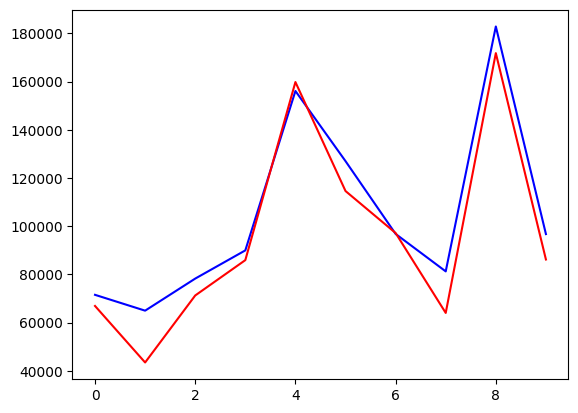

In [19]:
# Plotting of y_test vs y_pred

plt.plot(y_test, color = 'blue', label = 'test')
plt.plot(y_pred, color = 'red', label = 'predictions')
plt.show()